In [370]:
# === DATASET PARAMETERS
data_file          = "cancer.csv"          
separator          = r","             
header             = None                  
target_is_last     = True              
positive_class_val = 2                   
skip_first_rows    = 1                 

In [371]:
import pandas as pd
df_check = pd.read_csv(data_file, sep=separator, skiprows=skip_first_rows)
df = df.dropna()
print("Raw shape:", df_check.shape)
print("First row:\n", df_check.iloc[0])
print("Column names:", df_check.columns.tolist())

Raw shape: (456, 10)
First row:
 5       7
3       5
2      10
4      10
2.1    10
1      10
1.1     4
1.2    10
1.3     3
1.4     2
Name: 0, dtype: int64
Column names: ['5', '3', '2', '4', '2.1', '1', '1.1', '1.2', '1.3', '1.4']


In [372]:
X = df.iloc[:, :-1].values         # All columns except last
y_raw = df.iloc[:, -1].values      # Last column
y = np.where(y_raw == positive_class_val, 1, -1)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (457, 0), y shape: (457,)


In [373]:
mu    = X.mean(axis=0)
sigma = X.std(axis=0)
sigma[sigma == 0] = 1        
X_norm = (X - mu) / sigma

print("Feature means (should be ~0):", X_norm.mean(axis=0).round(4))
print("Feature stds  (should be ~1):",  X_norm.std(axis=0).round(4))

Feature means (should be ~0): []
Feature stds  (should be ~1): []


In [374]:
# Prepend bias column of ones — done ONCE only
X_bias = np.hstack([np.ones((X_norm.shape[0], 1)), X_norm])


N   = X_bias.shape[0]
idx = np.random.permutation(N)
Ntr = int(0.6 * N)

Xtr, ytr = X_bias[idx[:Ntr]], y[idx[:Ntr]]
Xte, yte = X_bias[idx[Ntr:]], y[idx[Ntr:]]

print(f"Training samples : {Xtr.shape[0]}")
print(f"Testing  samples : {Xte.shape[0]}")
print(f"Feature dimension (incl. bias): {Xtr.shape[1]}")

Training samples : 274
Testing  samples : 183
Feature dimension (incl. bias): 1


In [375]:
def sigmoid(s):
   
    return np.where(
        s >= 0,
        1.0 / (1.0 + np.exp(-s)),
        np.exp(s) / (1.0 + np.exp(s))
    )

def train_logistic(X, y, lr=0.08, n_iter=5000):
 
    n, d = X.shape
    w = np.zeros(d)
    loss_history = []
    for i in range(n_iter):
        margins = y * X.dot(w)
        probs   = sigmoid(-margins)
        grad    = (X.T.dot(y * probs)) / n   
        w      += lr * grad                  
        if i % 500 == 0:
            nll = -np.log(sigmoid(margins) + 1e-5).mean()
            loss_history.append((i, nll))
    return w, loss_history

def predict_logistic(X, w):
   
    return np.sign(X.dot(w)).astype(int)
    
def train_logistic_track(X, y, lr=0.08, n_iter=5000):
    
    n, d = X.shape
    w = np.zeros(d)
    losses = []
    for _ in range(n_iter):
        margins = y * X.dot(w)
        probs   = sigmoid(-margins)
        grad    = (X.T.dot(y * probs)) / n
        w      += lr * grad
        losses.append(-np.log(sigmoid(margins) + 1e-5).mean())
    return w, losses

In [376]:
w, loss_history = train_logistic(Xtr, ytr, lr=0.1, n_iter=5000)

feature_names = ["bias", "BP", "Cholesterol", "Age", "Pregnant"]
print("Final weight vector w:")
for name, wi in zip(feature_names, w):
    print(f"  {name:12s}: {wi:+.6f}")

Final weight vector w:
  bias        : -0.491408


In [377]:
y_pred_train = predict_logistic(Xtr, w)
train_accuracy = (y_pred_train == ytr).mean()
print(f"Training Accuracy: {train_accuracy:.4f}  ({train_accuracy*100:.1f}%)")

Training Accuracy: 0.6204  (62.0%)


In [378]:
y_pred = predict_logistic(Xte, w)

accuracy = (y_pred == yte).mean()
print("Predictions :", y_pred)
print("True labels :", yte)
print(f"\nTest Accuracy: {accuracy:.4f}  ({accuracy*100:.1f}%)")

Predictions : [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
True labels : [-1 -1 -1  1 -1 -1 -1  1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1 -1
 -1  1  1  1 -1 -1  1 -1  1  1 -1 -1 -1 -1  1  1  1 -1  1 -1 -1 -1 -1  1
  1 -1 -1 -1 -1  1  1 -1  1 -1  1  1 -1 -1 -1  1  1 -1 -1 -1  1 -1 -1  1
  1  1  1 -1  1 -1 -1 -1 -1 -1  1 -1 -1 -1  1  1 -1 -1 -1  1 -1  1  1 -1
  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1  1  1 -1
 -1  1 -1  1  1  1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 

In [379]:
TP = int(((y_pred ==  1) & (yte ==  1)).sum())
TN = int(((y_pred == -1) & (yte == -1)).sum())
FP = int(((y_pred ==  1) & (yte == -1)).sum())
FN = int(((y_pred == -1) & (yte ==  1)).sum())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

print(f"  TN={TN}  FP={FP}\n  FN={FN}  TP={TP}\n")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")

  TN=115  FP=0
  FN=68  TP=0

Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
Accuracy  : 0.6284  (62.8%)


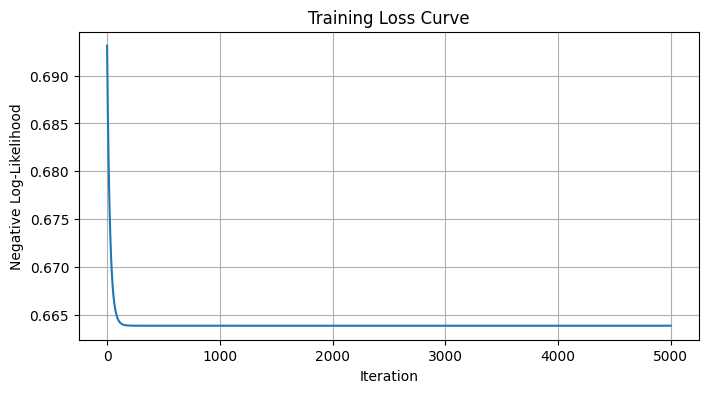

In [380]:
import matplotlib.pyplot as plt

_, losses = train_logistic_track(Xtr, ytr, lr=0.08, n_iter=5000)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()